In [1]:
# Install required libraries
!pip install transformers datasets scikit-learn torch --quiet

In [2]:
import pandas as pd
import numpy as np
import torch
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, mean_absolute_error
from torch.utils.data import Dataset, DataLoader
from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)
import warnings
warnings.filterwarnings('ignore')

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Using device: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

✅ Using device: cuda
   GPU: Tesla T4


In [4]:
from google.colab import files

print("📂 Please upload your CSV/Excel file...")
uploaded = files.upload()

# Get the uploaded filename automatically
filename = list(uploaded.keys())[0]

# Check file extension and use appropriate pandas reader
if filename.endswith('.csv'):
    df = pd.read_csv(filename)
elif filename.endswith(('.xls', '.xlsx')):
    df = pd.read_excel(filename)
else:
    raise ValueError("Unsupported file format. Please upload a CSV or Excel file.")

print(f"\n✅ Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"   Columns: {list(df.columns)}")
df.head()

📂 Please upload your CSV/Excel file...


Saving FoodReviews.xlsx to FoodReviews (1).xlsx

✅ Dataset loaded: 5000 rows, 5 columns
   Columns: ['ProductID', 'Helpfulness_Score', 'Rating', 'Review_Title', 'Text']


,ProductID,Helpfulness_Score,Rating,Review_Title,Text
0,CFB001E4K,1,5,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,CFB00813G,0,1,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,CFB000LQO,1,4,"""Delight"" says it all",This is a confection that has been around a fe...
3,CFB000UA0,3,2,Cough Medicine,If you are looking for the secret ingredient i...
4,CFB006K2Z,0,5,Great taffy,Great taffy at a great price. There was a wid...


In [5]:
# ── CONFIGURE COLUMN NAMES HERE if yours differ ──────────────────────────────
COL_TITLE  = 'Review_Title'   # Column with the short review title
COL_TEXT   = 'Text'           # Column with the full review text
COL_RATING = 'Rating'         # Column with the numeric rating (1–5)
# ─────────────────────────────────────────────────────────────────────────────

# Basic dataset info
print("📊 Rating Distribution:")
print(df[COL_RATING].value_counts().sort_index())
print(f"\n📊 Missing values:")
print(df[[COL_TITLE, COL_TEXT, COL_RATING]].isnull().sum())

📊 Rating Distribution:
Rating
1     469
2     290
3     395
4     712
5    3134
Name: count, dtype: int64

📊 Missing values:
Review_Title    0
Text            0
Rating          0
dtype: int64


In [6]:
# --- Drop rows with missing values in key columns ---
df = df.dropna(subset=[COL_TITLE, COL_TEXT, COL_RATING])
df[COL_RATING] = df[COL_RATING].astype(int)

# --- Combine title + text as model input ---
df['input_text'] = df[COL_TITLE].str.strip() + ' [SEP] ' + df[COL_TEXT].str.strip()

# --- Create sentiment labels from rating ---
def map_sentiment(rating):
    if rating >= 4: return 2   # Positive
    elif rating == 3: return 1 # Neutral
    else: return 0             # Negative

df['sentiment_label'] = df[COL_RATING].apply(map_sentiment)

# Rating label for the rating model (0-indexed: rating 1 → label 0)
df['rating_label'] = df[COL_RATING] - 1

# --- Sentiment label names (for reporting) ---
SENTIMENT_NAMES = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}

print("✅ Preprocessing complete!")
print(f"   Total samples: {len(df)}")
print("\n📊 Sentiment Label Distribution:")
counts = df['sentiment_label'].value_counts().sort_index()
for label, count in counts.items():
    print(f"   {SENTIMENT_NAMES[label]:10s}: {count} ({count/len(df)*100:.1f}%)")

df[['input_text', 'sentiment_label', 'rating_label']].head(3)

✅ Preprocessing complete!
   Total samples: 5000

📊 Sentiment Label Distribution:
   Negative  : 759 (15.2%)
   Neutral   : 395 (7.9%)
   Positive  : 3846 (76.9%)


,input_text,sentiment_label,rating_label
0,Good Quality Dog Food [SEP] I have bought seve...,2,4
1,Not as Advertised [SEP] Product arrived labele...,0,0
2,"""Delight"" says it all [SEP] This is a confecti...",2,3


In [7]:
from torch.nn import CrossEntropyLoss
import torch

# ── Compute class weights inversely proportional to frequency ─────────────────
label_counts = df['sentiment_label'].value_counts().sort_index()
total = len(df)

class_weights = torch.tensor([
    total / (3 * label_counts[0]),   # Negative  → highest weight
    total / (3 * label_counts[1]),   # Neutral   → high weight
    total / (3 * label_counts[2]),   # Positive  → lowest weight
], dtype=torch.float)

print("⚖️  Class Weights (to fix imbalance):")
print(f"   Negative : {class_weights[0]:.4f}")
print(f"   Neutral  : {class_weights[1]:.4f}")
print(f"   Positive : {class_weights[2]:.4f}")

⚖️  Class Weights (to fix imbalance):
   Negative : 2.1959
   Neutral  : 4.2194
   Positive : 0.4334


In [8]:
# --- Train / Validation / Test Split (70 / 15 / 15) ---
texts  = df['input_text'].tolist()
s_labels = df['sentiment_label'].tolist()  # sentiment
r_labels = df['rating_label'].tolist()      # rating

# First split: 85% train+val, 15% test
X_trainval, X_test, ys_trainval, ys_test, yr_trainval, yr_test = train_test_split(
    texts, s_labels, r_labels, test_size=0.15, random_state=42, stratify=s_labels
)

# Second split: 70% train, 15% val
X_train, X_val, ys_train, ys_val, yr_train, yr_val = train_test_split(
    X_trainval, ys_trainval, yr_trainval,
    test_size=0.176,  # 0.176 of 85% ≈ 15% of total
    random_state=42, stratify=ys_trainval
)

print(f"✅ Data split complete:")
print(f"   Train:      {len(X_train)} samples")
print(f"   Validation: {len(X_val)} samples")
print(f"   Test:       {len(X_test)} samples")

✅ Data split complete:
   Train:      3502 samples
   Validation: 748 samples
   Test:       750 samples


In [9]:
MODEL_NAME = 'distilbert-base-uncased'
MAX_LENGTH = 256   # 256 covers most reviews; use 512 if reviews are very long (slower)

print(f"⏳ Loading tokenizer: {MODEL_NAME}...")
tokenizer = DistilBertTokenizer.from_pretrained(MODEL_NAME)
print("✅ Tokenizer loaded!")

def tokenize(texts):
    return tokenizer(
        texts,
        truncation=True,
        padding=True,
        max_length=MAX_LENGTH,
        return_tensors='pt'
    )

print("⏳ Tokenizing train / val / test sets...")
train_encodings = tokenize(X_train)
val_encodings   = tokenize(X_val)
test_encodings  = tokenize(X_test)
print("✅ Tokenization complete!")

⏳ Loading tokenizer: distilbert-base-uncased...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

✅ Tokenizer loaded!
⏳ Tokenizing train / val / test sets...
✅ Tokenization complete!


In [10]:
class ReviewDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

# ── Sentiment Datasets ────────────────────────────────────────────────────────
sent_train_ds = ReviewDataset(train_encodings, ys_train)
sent_val_ds   = ReviewDataset(val_encodings,   ys_val)
sent_test_ds  = ReviewDataset(test_encodings,  ys_test)

# ── Rating Datasets ───────────────────────────────────────────────────────────
rate_train_ds = ReviewDataset(train_encodings, yr_train)
rate_val_ds   = ReviewDataset(val_encodings,   yr_val)
rate_test_ds  = ReviewDataset(test_encodings,  yr_test)

print(f"✅ Datasets ready!")
print(f"   Sentiment train: {len(sent_train_ds)} | val: {len(sent_val_ds)} | test: {len(sent_test_ds)}")
print(f"   Rating    train: {len(rate_train_ds)} | val: {len(rate_val_ds)} | test: {len(rate_test_ds)}")

✅ Datasets ready!
   Sentiment train: 3502 | val: 748 | test: 750
   Rating    train: 3502 | val: 748 | test: 750


In [11]:
def load_model(num_labels):
    model = DistilBertForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=num_labels
    )
    return model

# Metrics function used by Trainer
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    return {'accuracy': acc}

print("✅ Model loader ready. Models will be loaded in training sections.")

✅ Model loader ready. Models will be loaded in training sections.


In [13]:
print("⏳ Loading sentiment model (3 classes)...")
sentiment_model = load_model(num_labels=3)

sentiment_args = TrainingArguments(
    output_dir='./sentiment_checkpoints',
    num_train_epochs=4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=100,
    weight_decay=0.01,
    learning_rate=2e-5,
    eval_strategy='epoch',             # ← was: evaluation_strategy
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    logging_dir='./logs_sentiment',
    logging_steps=50,
    fp16=torch.cuda.is_available(),
    report_to='none'
)

from torch.nn import CrossEntropyLoss

# ── Custom Trainer that uses weighted loss ────────────────────────────────────
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        # Move weights to same device as model
        weights = class_weights.to(logits.device)
        loss_fn = CrossEntropyLoss(weight=weights)
        loss = loss_fn(logits, labels)

        return (loss, outputs) if return_outputs else loss

# ── WeightedTrainer with class weights ───────────────────────────────────────
sentiment_trainer = WeightedTrainer(
    model=sentiment_model,
    args=sentiment_args,
    train_dataset=sent_train_ds,
    eval_dataset=sent_val_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print("🚀 Starting Sentiment Model Training (with class weights)...")
sentiment_trainer.train()
print("\n✅ Sentiment model training complete!")

⏳ Loading sentiment model (3 classes)...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


🚀 Starting Sentiment Model Training (with class weights)...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.686796,0.799160,0.848930
2,0.571596,0.589994,0.794118
3,0.413738,0.757667,0.864973
4,0.257631,0.924225,0.874332


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Sentiment model training complete!


In [14]:
print("⏳ Loading rating model (5 classes)...")
rating_model = load_model(num_labels=5)

rating_args = TrainingArguments(
    output_dir='./rating_checkpoints',
    num_train_epochs=4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=100,
    weight_decay=0.01,
    learning_rate=2e-5,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    logging_dir='./logs_rating',
    logging_steps=50,
    fp16=torch.cuda.is_available(),
    report_to='none'
)

rating_trainer = Trainer(
    model=rating_model,
    args=rating_args,
    train_dataset=rate_train_ds,
    eval_dataset=rate_val_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print("🚀 Starting Rating Model Training...")
rating_trainer.train()
print("\n✅ Rating model training complete!")

⏳ Loading rating model (5 classes)...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


🚀 Starting Rating Model Training...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.816976,0.760684,0.709893
2,0.626688,0.745843,0.720588
3,0.519510,0.728624,0.721925
4,0.392293,0.743370,0.728610


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Rating model training complete!


In [15]:
# ── Sentiment Evaluation ──────────────────────────────────────────────────────
print("=" * 55)
print("📊 SENTIMENT MODEL — Test Set Evaluation")
print("=" * 55)

sent_preds_output = sentiment_trainer.predict(sent_test_ds)
sent_preds = np.argmax(sent_preds_output.predictions, axis=-1)
sent_true  = sent_preds_output.label_ids

print(f"\nOverall Accuracy: {accuracy_score(sent_true, sent_preds)*100:.2f}%\n")
print(classification_report(
    sent_true, sent_preds,
    target_names=['Negative', 'Neutral', 'Positive']
))

📊 SENTIMENT MODEL — Test Set Evaluation



Overall Accuracy: 88.67%

              precision    recall  f1-score   support

    Negative       0.78      0.82      0.80       114
     Neutral       0.45      0.42      0.44        59
    Positive       0.95      0.95      0.95       577

    accuracy                           0.89       750
   macro avg       0.73      0.73      0.73       750
weighted avg       0.89      0.89      0.89       750



In [16]:
# ── Rating Evaluation ─────────────────────────────────────────────────────────
print("=" * 55)
print("📊 RATING MODEL — Test Set Evaluation")
print("=" * 55)

rate_preds_output = rating_trainer.predict(rate_test_ds)
rate_preds = np.argmax(rate_preds_output.predictions, axis=-1)
rate_true  = rate_preds_output.label_ids

# Convert back to 1–5 scale
rate_preds_stars = rate_preds + 1
rate_true_stars  = rate_true  + 1

print(f"\nExact Accuracy : {accuracy_score(rate_true, rate_preds)*100:.2f}%")
print(f"Mean Abs Error : {mean_absolute_error(rate_true_stars, rate_preds_stars):.3f} stars\n")
print(classification_report(
    rate_true_stars, rate_preds_stars,
    target_names=['1 Star','2 Stars','3 Stars','4 Stars','5 Stars']
))

📊 RATING MODEL — Test Set Evaluation



Exact Accuracy : 74.27%
Mean Abs Error : 0.339 stars

              precision    recall  f1-score   support

      1 Star       0.69      0.81      0.74        68
     2 Stars       0.45      0.30      0.36        46
     3 Stars       0.51      0.39      0.44        59
     4 Stars       0.42      0.40      0.41       111
     5 Stars       0.86      0.90      0.88       466

    accuracy                           0.74       750
   macro avg       0.59      0.56      0.57       750
weighted avg       0.73      0.74      0.73       750



In [17]:
import shutil

# ── Save Sentiment Model ──────────────────────────────────────────────────────
SENTIMENT_SAVE_PATH = './saved_sentiment_model'
sentiment_model.save_pretrained(SENTIMENT_SAVE_PATH)
tokenizer.save_pretrained(SENTIMENT_SAVE_PATH)

# Save label mapping
import json
with open(f'{SENTIMENT_SAVE_PATH}/label_map.json', 'w') as f:
    json.dump({"0": "Negative", "1": "Neutral", "2": "Positive"}, f)

print(f"✅ Sentiment model saved to: {SENTIMENT_SAVE_PATH}")

# ── Save Rating Model ─────────────────────────────────────────────────────────
RATING_SAVE_PATH = './saved_rating_model'
rating_model.save_pretrained(RATING_SAVE_PATH)
tokenizer.save_pretrained(RATING_SAVE_PATH)

with open(f'{RATING_SAVE_PATH}/label_map.json', 'w') as f:
    json.dump({"0": "1 Star", "1": "2 Stars", "2": "3 Stars", "3": "4 Stars", "4": "5 Stars"}, f)

print(f"✅ Rating model saved to:    {RATING_SAVE_PATH}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Sentiment model saved to: ./saved_sentiment_model


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Rating model saved to:    ./saved_rating_model


In [18]:
# ── Zip & Download ────────────────────────────────────────────────────────────
from google.colab import files

print("⏳ Zipping models...")

shutil.make_archive('sentiment_model', 'zip', SENTIMENT_SAVE_PATH)
shutil.make_archive('rating_model',    'zip', RATING_SAVE_PATH)

print("📥 Downloading sentiment_model.zip...")
files.download('sentiment_model.zip')

print("📥 Downloading rating_model.zip...")
files.download('rating_model.zip')

print("\n✅ Both models downloaded!")

⏳ Zipping models...
📥 Downloading sentiment_model.zip...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Downloading rating_model.zip...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Both models downloaded!


In [19]:
# ── Section 9B — Evaluation Graphs ───────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

sns.set_theme(style='whitegrid', font_scale=1.1)
SENTIMENT_NAMES = ['Negative', 'Neutral', 'Positive']
RATING_NAMES    = ['1 Star', '2 Stars', '3 Stars', '4 Stars', '5 Stars']

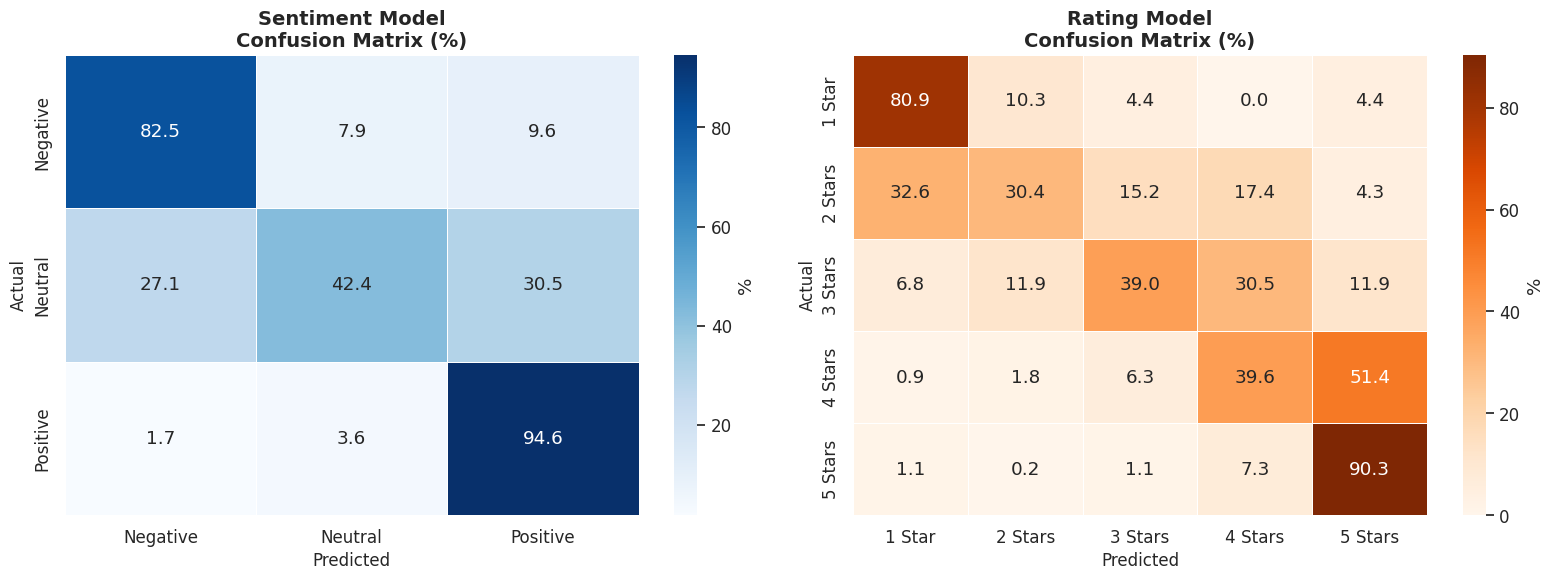

✅ Confusion matrices saved!


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Sentiment Confusion Matrix ────────────────────────────────────────────────
cm_sent = confusion_matrix(sent_true, sent_preds)
cm_sent_pct = cm_sent.astype('float') / cm_sent.sum(axis=1, keepdims=True) * 100

sns.heatmap(
    cm_sent_pct, annot=True, fmt='.1f', cmap='Blues',
    xticklabels=SENTIMENT_NAMES, yticklabels=SENTIMENT_NAMES,
    ax=axes[0], linewidths=0.5, cbar_kws={'label': '%'}
)
axes[0].set_title('Sentiment Model\nConfusion Matrix (%)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_xlabel('Predicted', fontsize=12)

# ── Rating Confusion Matrix ───────────────────────────────────────────────────
cm_rate = confusion_matrix(rate_true_stars, rate_preds_stars)
cm_rate_pct = cm_rate.astype('float') / cm_rate.sum(axis=1, keepdims=True) * 100

sns.heatmap(
    cm_rate_pct, annot=True, fmt='.1f', cmap='Oranges',
    xticklabels=RATING_NAMES, yticklabels=RATING_NAMES,
    ax=axes[1], linewidths=0.5, cbar_kws={'label': '%'}
)
axes[1].set_title('Rating Model\nConfusion Matrix (%)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Actual', fontsize=12)
axes[1].set_xlabel('Predicted', fontsize=12)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrices saved!")

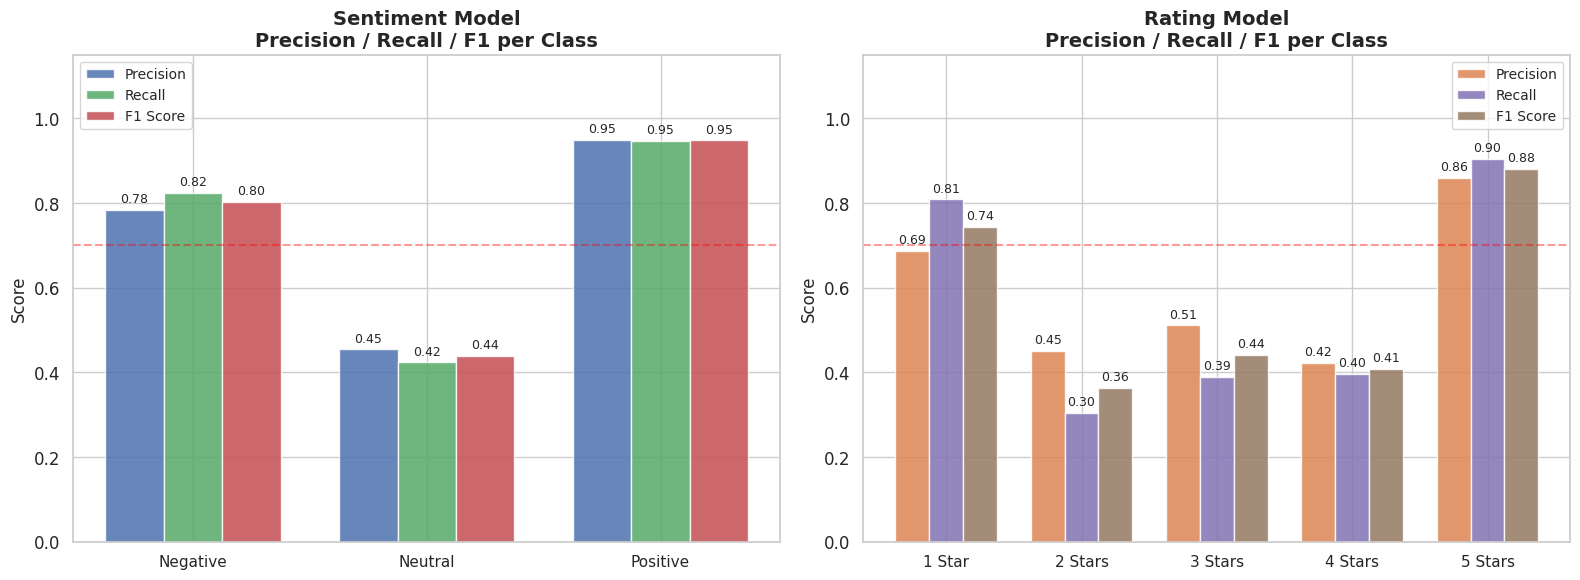

✅ Per-class metrics saved!


In [21]:
from sklearn.metrics import precision_recall_fscore_support

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

def plot_metrics_bar(ax, true, preds, class_names, title, color):
    precision, recall, f1, _ = precision_recall_fscore_support(
        true, preds, average=None
    )
    x = np.arange(len(class_names))
    width = 0.25

    bars1 = ax.bar(x - width, precision, width, label='Precision', color=color[0], alpha=0.85)
    bars2 = ax.bar(x,         recall,    width, label='Recall',    color=color[1], alpha=0.85)
    bars3 = ax.bar(x + width, f1,        width, label='F1 Score',  color=color[2], alpha=0.85)

    # Add value labels on bars
    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f'{bar.get_height():.2f}',
                ha='center', va='bottom', fontsize=9
            )

    ax.set_xticks(x)
    ax.set_xticklabels(class_names, fontsize=11)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.axhline(y=0.7, color='red', linestyle='--', alpha=0.4, label='0.7 threshold')

# Sentiment
plot_metrics_bar(
    axes[0], sent_true, sent_preds, SENTIMENT_NAMES,
    'Sentiment Model\nPrecision / Recall / F1 per Class',
    ['#4C72B0', '#55A868', '#C44E52']
)

# Rating
plot_metrics_bar(
    axes[1], rate_true_stars, rate_preds_stars, RATING_NAMES,
    'Rating Model\nPrecision / Recall / F1 per Class',
    ['#DD8452', '#8172B3', '#937860']
)

plt.tight_layout()
plt.savefig('per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Per-class metrics saved!")

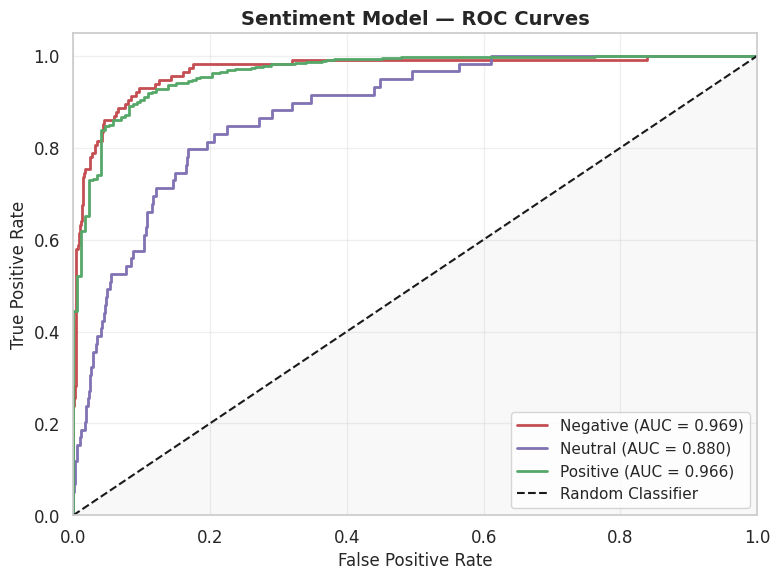

✅ ROC curves saved!


In [22]:
# Binarize labels for multi-class ROC
sent_true_bin = label_binarize(sent_true, classes=[0, 1, 2])
sent_probs_all = torch.softmax(
    torch.tensor(sent_preds_output.predictions), dim=1
).numpy()

fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#C44E52', '#8172B3', '#55A868']
for i, (name, color) in enumerate(zip(SENTIMENT_NAMES, colors)):
    fpr, tpr, _ = roc_curve(sent_true_bin[:, i], sent_probs_all[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{name} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Sentiment Model — ROC Curves', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ ROC curves saved!")

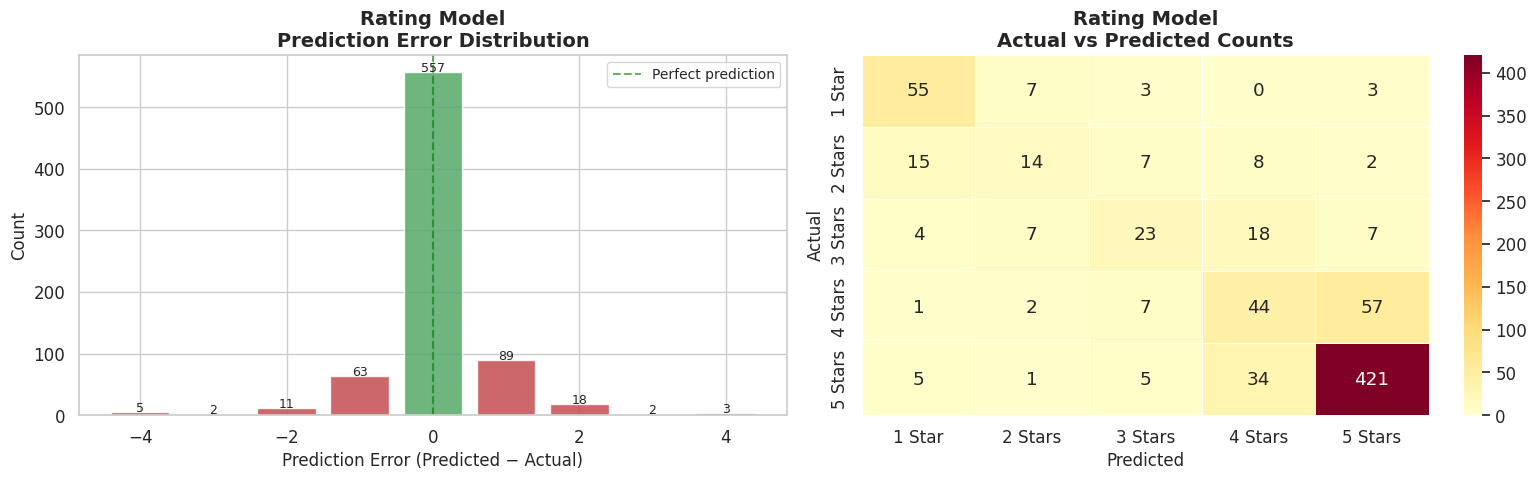

✅ Rating error distribution saved!


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Error distribution ────────────────────────────────────────────────────────
errors = np.array(rate_preds_stars) - np.array(rate_true_stars)
error_counts = {i: (errors == i).sum() for i in range(-4, 5)}

axes[0].bar(
    error_counts.keys(), error_counts.values(),
    color=['#C44E52' if k != 0 else '#55A868' for k in error_counts.keys()],
    alpha=0.85, edgecolor='white'
)
axes[0].set_xlabel('Prediction Error (Predicted − Actual)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Rating Model\nPrediction Error Distribution', fontsize=14, fontweight='bold')
axes[0].axvline(x=0, color='green', linestyle='--', alpha=0.6, label='Perfect prediction')
axes[0].legend(fontsize=10)

for k, v in error_counts.items():
    if v > 0:
        axes[0].text(k, v + 1, str(v), ha='center', fontsize=9)

# ── Actual vs Predicted heatmap ───────────────────────────────────────────────
actual_vs_pred = np.zeros((5, 5), dtype=int)
for t, p in zip(rate_true_stars, rate_preds_stars):
    actual_vs_pred[t-1][p-1] += 1

sns.heatmap(
    actual_vs_pred, annot=True, fmt='d', cmap='YlOrRd',
    xticklabels=RATING_NAMES, yticklabels=RATING_NAMES,
    ax=axes[1], linewidths=0.5
)
axes[1].set_title('Rating Model\nActual vs Predicted Counts', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Actual', fontsize=12)
axes[1].set_xlabel('Predicted', fontsize=12)

plt.tight_layout()
plt.savefig('rating_error_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Rating error distribution saved!")